# Automated Customer Segmentation (RFM) Analytics Engine

## Overview
This project analyzes ~540,000 e-commerce transactions from a UK-based online retailer 
to segment customers based on **Recency, Frequency, and Monetary (RFM)** value — a 
widely-used framework in marketing analytics for customer relationship management (CRM).

## Business Objective
Identify high-value customer segments to enable targeted marketing strategies:
- Reward and retain top spenders ("Champions")
- Re-engage customers showing signs of churn ("At Risk", "Cant Lose Them")
- Nurture emerging customers into loyal, repeat buyers

## Dataset
- Source: UCI Machine Learning Repository — Online Retail Dataset
- ~540,000 transaction records, Dec 2010 – Dec 2011, UK-based online retailer

## Methodology
1. Data Cleaning: removed missing CustomerIDs, cancellations/returns, duplicates
2. RFM Calculation: computed Recency, Frequency, and Monetary value per customer
3. Scoring: assigned 1-5 quintile scores for each RFM dimension
4. Segmentation: mapped score combinations to business-relevant segments (Champions, 
   Loyal Customers, At Risk, etc.)
5. Visualization: analyzed segment size and revenue contribution

## Key Finding
**"Champions" represent ~26% of the customer base but generate 66.5% of total revenue** 
— highlighting the importance of retention strategies for this segment.

In [29]:
# ===== CONFIGURATION =====
# Define column mappings here - change these if using a different dataset
COL_INVOICE = 'InvoiceNo'
COL_CUSTOMER = 'CustomerID'
COL_DATE = 'InvoiceDate'
COL_QUANTITY = 'Quantity'
COL_PRICE = 'UnitPrice'

DATA_FILE = 'online_retail.xlsx'

In [30]:
import pandas as pd

df = pd.read_excel(DATA_FILE)
print(df.shape)
df.head()

(541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [31]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

print("\nNegative Quantity rows:", (df['Quantity'] < 0).sum())
print("Duplicate rows:", df.duplicated().sum())

Missing values per column:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Negative Quantity rows: 10624
Duplicate rows: 5268


## Step 2: Data Cleaning
Removing records with missing customer IDs, duplicate entries, returns/cancellations 
(negative quantities), and invalid prices — then engineering a `TotalPrice` feature.

In [32]:
# Step 1: Remove rows with missing CustomerID
df = df.dropna(subset=[COL_CUSTOMER])

# Step 2: Remove duplicate rows
df = df.drop_duplicates()

# Step 3: Remove rows where Quantity is negative or zero (returns/cancellations)
df = df[df[COL_QUANTITY] > 0]

# Step 4: Remove rows where UnitPrice is zero or negative (free items/errors)
df = df[df[COL_PRICE] > 0]

# Step 5: Create a TotalPrice column (this is needed for "Monetary" in RFM)
df['TotalPrice'] = df[COL_QUANTITY] * df[COL_PRICE]

# Step 6: Convert CustomerID to integer (currently it's a float like 17850.0)
df[COL_CUSTOMER] = df[COL_CUSTOMER].astype(int)

# Check the cleaned data
print("Shape after cleaning:", df.shape)
print("\nMissing values now:")
print(df.isnull().sum())
df.head()

Shape after cleaning: (392692, 9)

Missing values now:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
TotalPrice     0
dtype: int64


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


## Step 3: RFM Metric Calculation
Computing Recency (days since last purchase), Frequency (number of unique orders), 
and Monetary (total spend) for each customer.

In [33]:
import datetime as dt

# Set a reference date = one day after the most recent invoice date in the data
reference_date = df[COL_DATE].max() + dt.timedelta(days=1)
print("Reference date:", reference_date)

# Group by CustomerID and calculate R, F, M
rfm = df.groupby(COL_CUSTOMER).agg({
    COL_DATE: lambda x: (reference_date - x.max()).days,  # Recency
    COL_INVOICE: 'nunique',                                 # Frequency
    'TotalPrice': 'sum'                                     # Monetary
})

# Rename columns to standard RFM names
rfm.columns = ['Recency', 'Frequency', 'Monetary']

print("RFM table shape:", rfm.shape)
rfm.head(10)

Reference date: 2011-12-10 12:50:00
RFM table shape: (4338, 3)


,Recency,Frequency,Monetary
CustomerID,,,
12346,326,1,77183.60
12347,2,7,4310.00
12348,75,4,1797.24
12349,19,1,1757.55
12350,310,1,334.40
12352,36,8,2506.04
12353,204,1,89.00
12354,232,1,1079.40
12355,214,1,459.40


## Step 4: RFM Scoring & Customer Segmentation
Scoring each customer 1-5 on each RFM dimension using quintiles, then mapping score 
combinations to actionable business segments.

In [34]:
# Score each metric from 1 to 5 using quintiles
# Recency: lower is better, so we reverse the labels
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=5, labels=[5, 4, 3, 2, 1])

# Frequency: higher is better. Use rank() first to handle duplicate values safely
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5])

# Monetary: higher is better
rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=5, labels=[1, 2, 3, 4, 5])

# Combine into a single RFM score (string, e.g. "555")
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

print(rfm.head(10))

            Recency  Frequency  Monetary R_Score F_Score M_Score RFM_Score
CustomerID                                                                
12346           326          1  77183.60       1       1       5       115
12347             2          7   4310.00       5       5       5       555
12348            75          4   1797.24       2       4       4       244
12349            19          1   1757.55       4       1       4       414
12350           310          1    334.40       1       1       2       112
12352            36          8   2506.04       3       5       5       355
12353           204          1     89.00       1       1       1       111
12354           232          1   1079.40       1       1       4       114
12355           214          1    459.40       1       1       2       112
12356            23          3   2811.43       4       3       5       435


In [35]:
# Define a function to assign a segment name based on R and F scores
def segment_customer(row):
    r = int(row['R_Score'])
    f = int(row['F_Score'])
    
    if r >= 4 and f >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'New Customers'
    elif r == 3 and f <= 2:
        return 'Potential Loyalists'
    elif r <= 2 and f >= 4:
        return 'At Risk'
    elif r <= 2 and f == 3:
        return 'Needs Attention'
    elif r <= 2 and f <= 2 and row['M_Score'] >= 4:
        return 'Cant Lose Them'
    else:
        return 'Lost'

# Apply the function to every row
rfm['Segment'] = rfm.apply(segment_customer, axis=1)

# See how many customers fall into each segment
print(rfm['Segment'].value_counts())

rfm.head(10)

Segment
Champions              1139
Lost                    987
Loyal Customers         821
Needs Attention         368
Potential Loyalists     351
New Customers           319
At Risk                 275
Cant Lose Them           78
Name: count, dtype: int64


,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
CustomerID,,,,,,,,
12346,326,1,77183.60,1,1,5,115,Cant Lose Them
12347,2,7,4310.00,5,5,5,555,Champions
12348,75,4,1797.24,2,4,4,244,At Risk
12349,19,1,1757.55,4,1,4,414,New Customers
12350,310,1,334.40,1,1,2,112,Lost
12352,36,8,2506.04,3,5,5,355,Loyal Customers
12353,204,1,89.00,1,1,1,111,Lost
12354,232,1,1079.40,1,1,4,114,Cant Lose Them
12355,214,1,459.40,1,1,2,112,Lost


## Step 5: Visualization & Insights

In [36]:
# Score each metric from 1 to 5 using quintiles
# Recency: lower is better, so we reverse the labels
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=5, labels=[5, 4, 3, 2, 1])

# Frequency: higher is better. Use rank() first to handle duplicate values safely
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5])

# Monetary: higher is better
rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=5, labels=[1, 2, 3, 4, 5])

# Combine into a single RFM score (string, e.g. "555")
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

print(rfm.head(10))

            Recency  Frequency  Monetary R_Score F_Score M_Score RFM_Score  \
CustomerID                                                                   
12346           326          1  77183.60       1       1       5       115   
12347             2          7   4310.00       5       5       5       555   
12348            75          4   1797.24       2       4       4       244   
12349            19          1   1757.55       4       1       4       414   
12350           310          1    334.40       1       1       2       112   
12352            36          8   2506.04       3       5       5       355   
12353           204          1     89.00       1       1       1       111   
12354           232          1   1079.40       1       1       4       114   
12355           214          1    459.40       1       1       2       112   
12356            23          3   2811.43       4       3       5       435   

                    Segment  
CustomerID                   
123

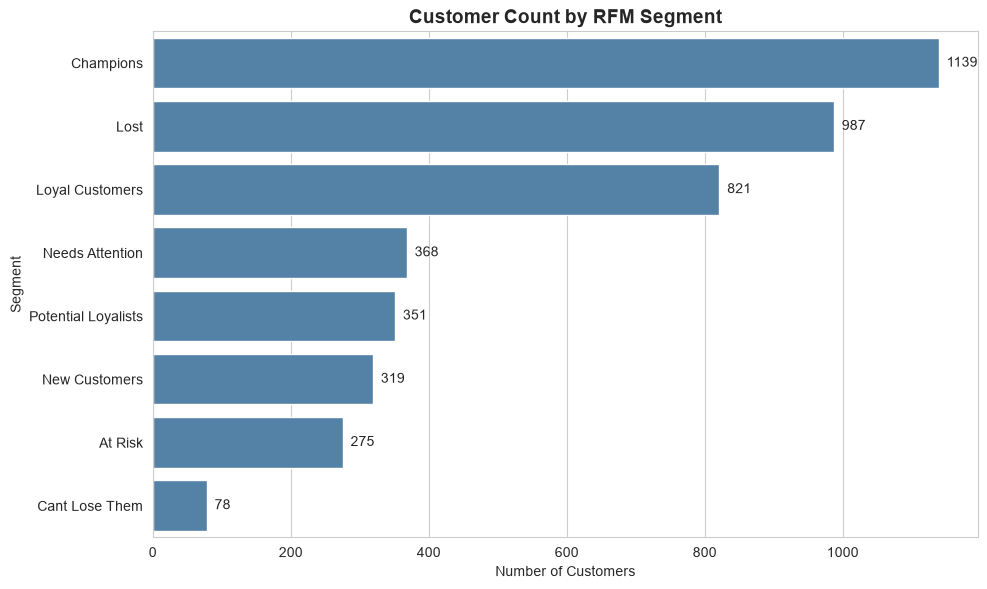

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a nice style
sns.set_style('whitegrid')

# Chart 1: Number of customers per segment
plt.figure(figsize=(10, 6))
segment_counts = rfm['Segment'].value_counts()
sns.barplot(x=segment_counts.values, y=segment_counts.index, color='steelblue')
plt.title('Customer Count by RFM Segment', fontsize=14, fontweight='bold')
plt.xlabel('Number of Customers')
plt.ylabel('Segment')

# Add count labels on each bar
for i, value in enumerate(segment_counts.values):
    plt.text(value, i, f'  {value}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('segment_counts.png', dpi=300)
plt.show()

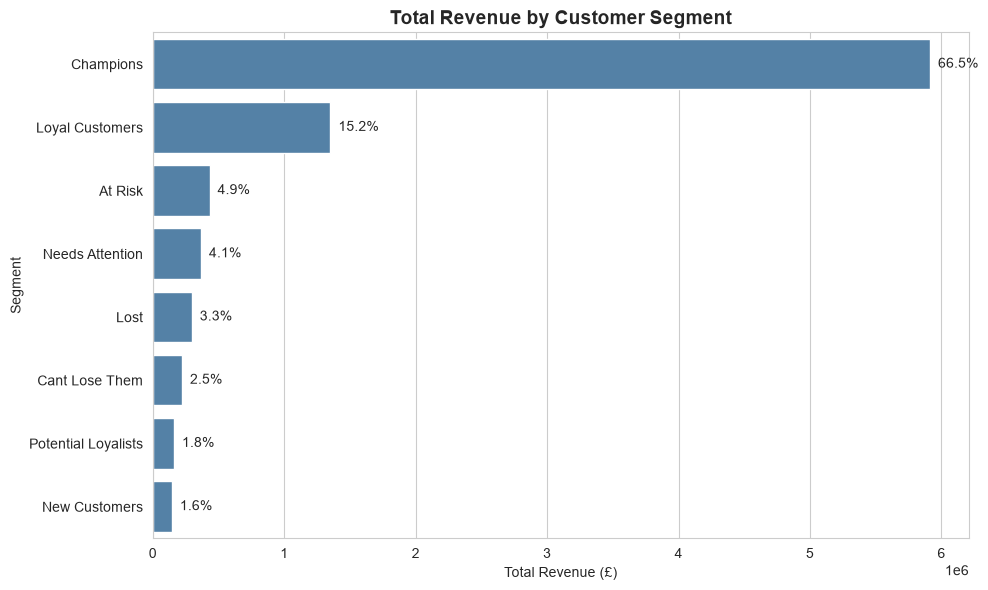

Segment
Champions              5913422.081
Loyal Customers        1351084.300
At Risk                 431639.270
Needs Attention         366413.241
Lost                    296507.741
Cant Lose Them          221814.411
Potential Loyalists     161108.110
New Customers           145219.740
Name: Monetary, dtype: float64

Percentage of total revenue:
Segment
Champions              66.5
Loyal Customers        15.2
At Risk                 4.9
Needs Attention         4.1
Lost                    3.3
Cant Lose Them          2.5
Potential Loyalists     1.8
New Customers           1.6
Name: Monetary, dtype: float64


In [38]:
# Chart 2: Revenue contribution by segment
revenue_by_segment = rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False)

# Calculate percentage of total revenue
revenue_pct = (revenue_by_segment / revenue_by_segment.sum() * 100).round(1)

plt.figure(figsize=(10, 6))
sns.barplot(x=revenue_by_segment.values, y=revenue_by_segment.index, color='steelblue')
plt.title('Total Revenue by Customer Segment', fontsize=14, fontweight='bold')
plt.xlabel('Total Revenue (£)')
plt.ylabel('Segment')

# Add percentage labels on each bar
for i, (value, pct) in enumerate(zip(revenue_by_segment.values, revenue_pct.values)):
    plt.text(value, i, f'  {pct}%', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('revenue_by_segment.png', dpi=300)
plt.show()

print(revenue_by_segment)
print("\nPercentage of total revenue:")
print(revenue_pct)

In [39]:
# Save the full RFM table (with segments) to a CSV file
rfm_export = rfm.reset_index()  # turns CustomerID from index back into a column
rfm_export.to_csv('rfm_segmentation_output.csv', index=False)

print("Saved successfully!")
print(rfm_export.shape)
rfm_export.head()

Saved successfully!
(4338, 9)


,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
0,12346,326,1,77183.60,1,1,5,115,Cant Lose Them
1,12347,2,7,4310.00,5,5,5,555,Champions
2,12348,75,4,1797.24,2,4,4,244,At Risk
3,12349,19,1,1757.55,4,1,4,414,New Customers
4,12350,310,1,334.40,1,1,2,112,Lost
